# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [26]:
# untuk plot Q-Q
import scipy.stats as stats

In [31]:
df_california = pd.read_csv('california_dataset.csv')


In [28]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [29]:
import pandas as pd

# membaca dataset
df = pd.read_csv('california_dataset.csv')

# cek data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


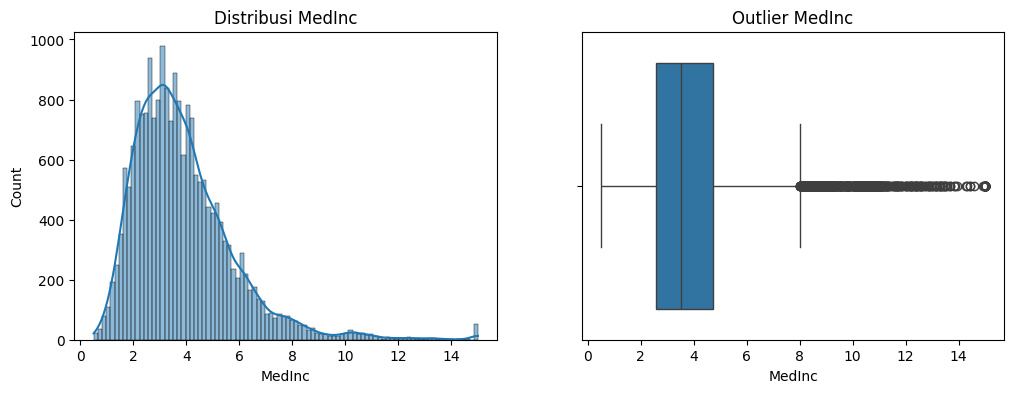

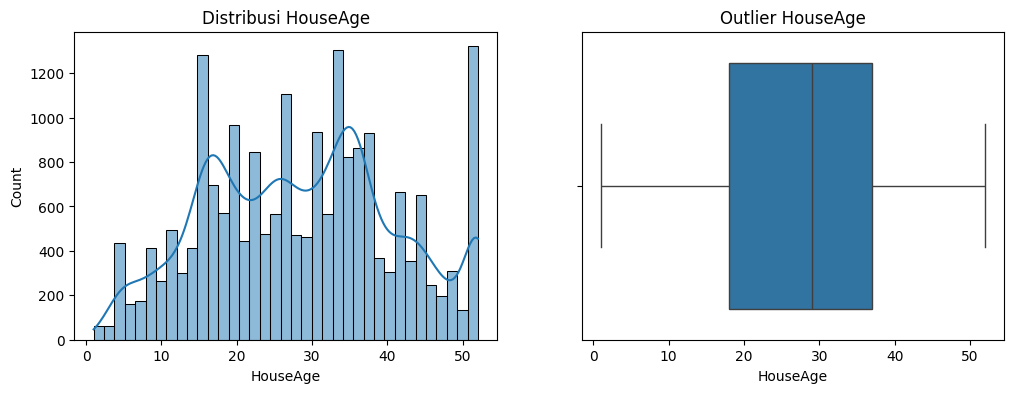

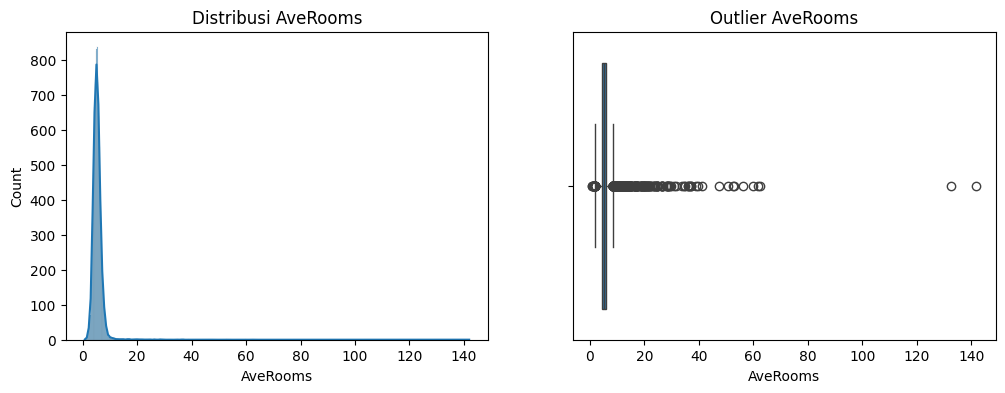

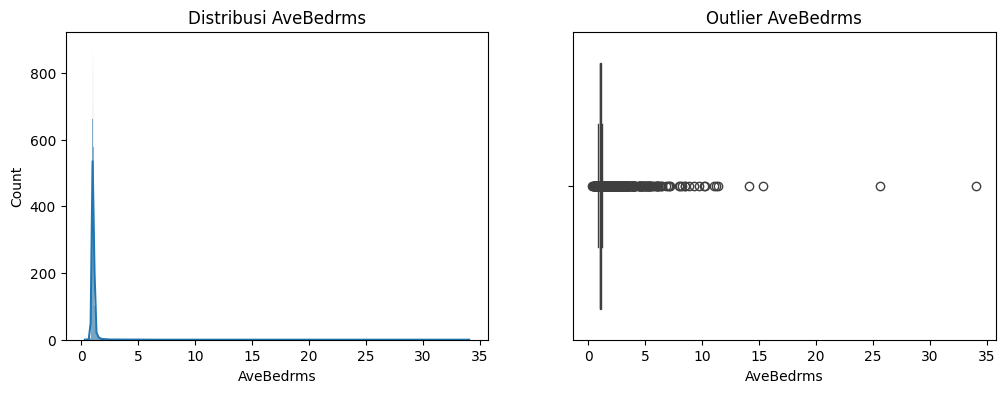

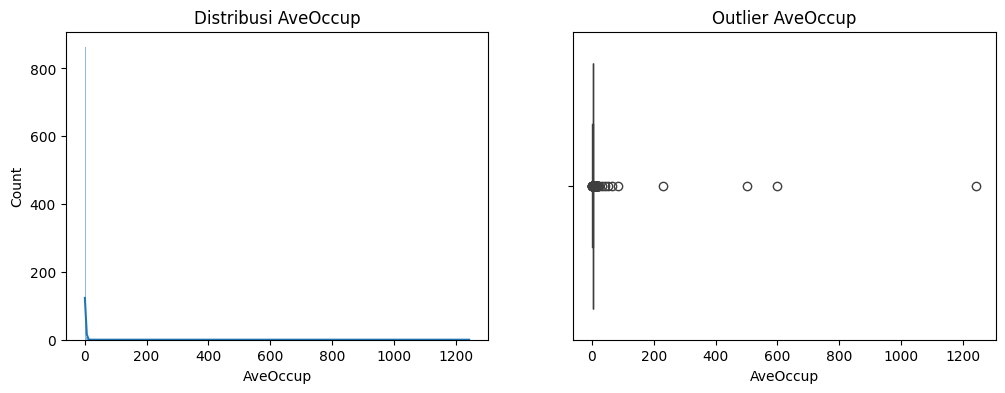

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_kolom = ['MedInc','HouseAge','AveRooms','AveBedrms','AveOccup']

for kolom in kolom_kolom:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Outlier {kolom}')

    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

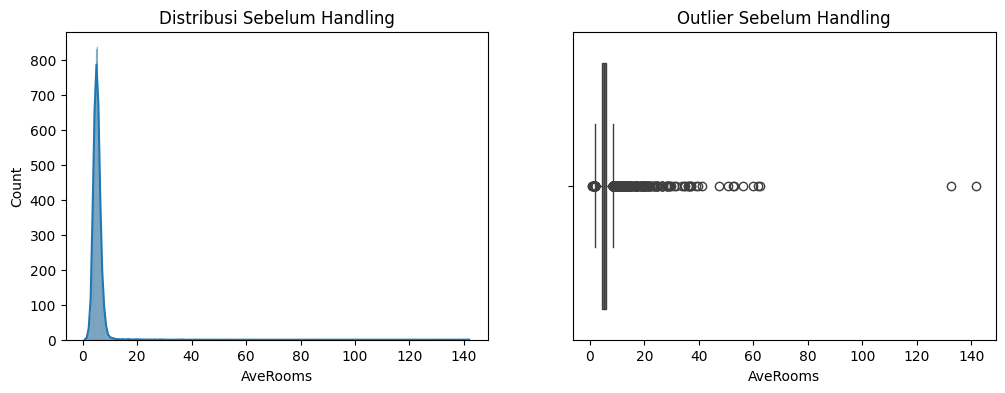

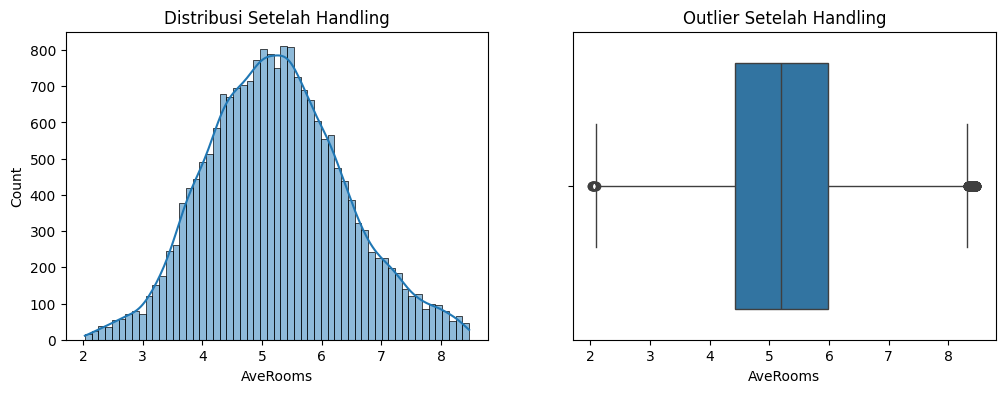

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom = 'AveRooms'

# Distribusi sebelum handling
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df[kolom], kde=True)
plt.title('Distribusi Sebelum Handling')

plt.subplot(1,2,2)
sns.boxplot(x=df[kolom])
plt.title('Outlier Sebelum Handling')

plt.show()


# IQR method
Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df[kolom] >= lower) & (df[kolom] <= upper)]


# Distribusi setelah handling
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_clean[kolom], kde=True)
plt.title('Distribusi Setelah Handling')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean[kolom])
plt.title('Outlier Setelah Handling')

plt.show()

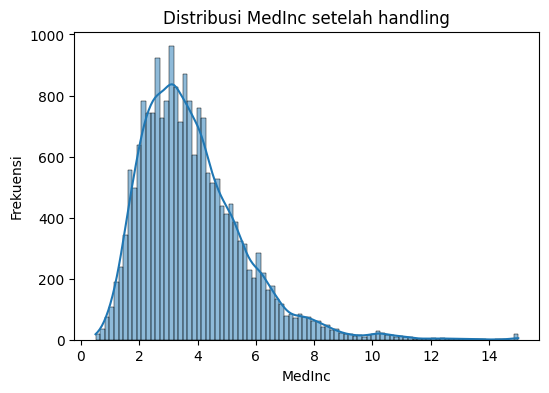

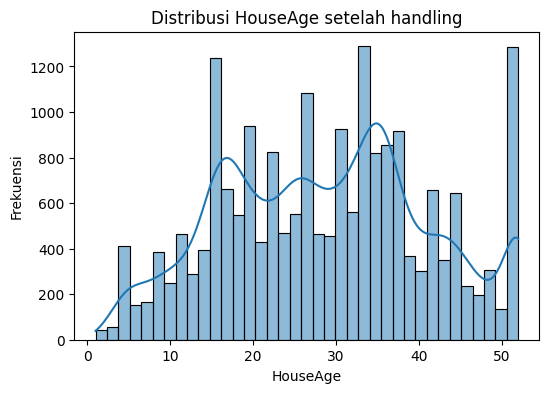

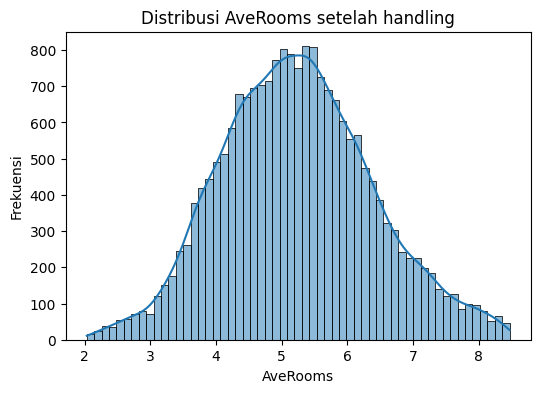

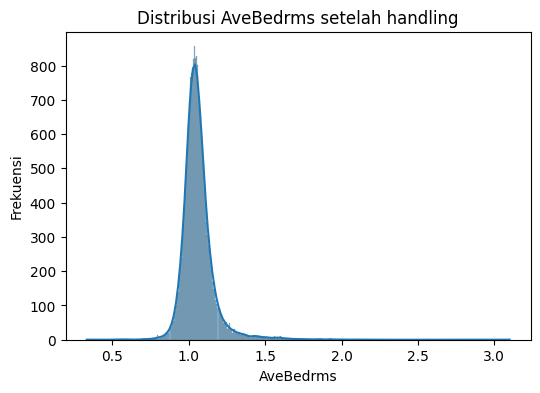

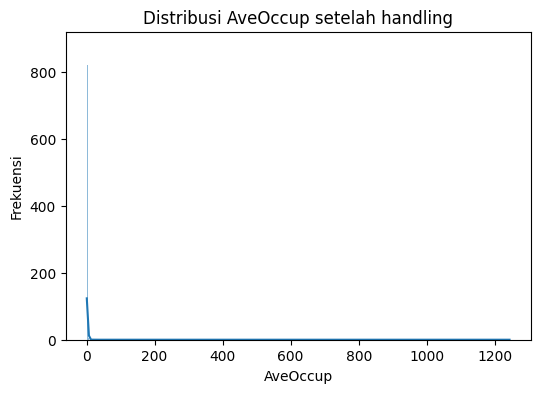

In [41]:
# Melakukan loop untuk mengecek distribusi tiap kolom

kolom_kolom = ['MedInc','HouseAge','AveRooms','AveBedrms','AveOccup']

for kolom in kolom_kolom:
    plt.figure(figsize=(6,4))
    sns.histplot(df_clean[kolom], kde=True)
    plt.title(f'Distribusi {kolom} setelah handling')
    plt.xlabel(kolom)
    plt.ylabel("Frekuensi")
    plt.show()



# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [91]:
df_company = pd.read_csv('company.csv')
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [92]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [93]:
df_company.isna().sum()

,0
Revenue,0
Size,0
Rating,0
Headquarters,0


In [94]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


,count
Revenue,
Unknown / Non-Applicable,213
$100 to $500 million (USD),94
$10+ billion (USD),63
$2 to $5 billion (USD),45
$10 to $25 million (USD),41
$1 to $2 billion (USD),36
$25 to $50 million (USD),36
$50 to $100 million (USD),31
$1 to $5 million (USD),31



============= Size =================


,count
Size,
51 to 200 employees,135
1001 to 5000 employees,104
1 to 50 employees,86
201 to 500 employees,85
10000+ employees,80
501 to 1000 employees,77
5001 to 10000 employees,61
-1,27
Unknown,17



============= Rating =================


,count
Rating,
3.5,58
-1.0,50
3.3,41
4.0,41
3.9,40
3.8,39
3.7,38
5.0,36
4.5,32



============= Headquarters =================


,count
Headquarters,
"New York, NY",33
"San Francisco, CA",31
-1,31
"Chicago, IL",23
"Boston, MA",19
"Reston, VA",14
"Mc Lean, VA",13
"Westminster, CO",12
"Cambridge, MA",10


In [95]:
missing = (df_company['Headquarters'] == '-1').sum()
total = len(df_company)

persentase = (missing / total) * 100

print("Jumlah missing value:", missing)
print("Total data:", total)
print("Persentase missing value:", persentase,"%")

Jumlah missing value: 31
Total data: 672
Persentase missing value: 4.613095238095238 %


In [96]:
import numpy as np

df_company['Headquarters'] = df_company['Headquarters'].replace('-1', np.nan)

In [97]:
df_company['Headquarters'].isna().sum()

np.int64(31)

In [98]:
mode_value = df_company['Headquarters'].mode()[0]

df_company['Headquarters'] = df_company['Headquarters'].fillna(mode_value)

In [99]:
df_company['Headquarters'].isna().sum()

np.int64(0)

In [100]:
print("Jumlah missing value:", df_company['Headquarters'].isna().sum())

Jumlah missing value: 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [113]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [111]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [112]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
cols = [
    'StreamingMovies',
    'StreamingTV',
    'TechSupport',
    'DeviceProtection',
    'OnlineBackup',
    'OnlineSecurity',
    'MultipleLines'
]

In [114]:
df_churn['Churn'] = df_churn['Churn'].replace('No internet service', 'No')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [116]:
for column in columns_check:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


,count
StreamingMovies,
No,2785
Yes,2732
No internet service,1526



============= StreamingTV =================


,count
StreamingTV,
No,2810
Yes,2707
No internet service,1526



============= TechSupport =================


...

,count
OnlineBackup,
No,3088
Yes,2429
No internet service,1526



============= OnlineSecurity =================


,count
OnlineSecurity,
No,3498
Yes,2019
No internet service,1526



============= MultipleLines =================


,count
MultipleLines,
No,3390
Yes,2971
No phone service,682


In [117]:
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})

In [119]:
for column in columns_check:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


,count
StreamingMovies,
No,4311
Yes,2732



============= StreamingTV =================


,count
StreamingTV,
No,4336
Yes,2707



============= TechSupport =================


...

,count
OnlineBackup,
No,4614
Yes,2429



============= OnlineSecurity =================


,count
OnlineSecurity,
No,5024
Yes,2019



============= MultipleLines =================


,count
MultipleLines,
No,4072
Yes,2971


In [120]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_churn['StreamingMovies'] = le.fit_transform(df_churn['StreamingMovies'])
df_churn['StreamingTV'] = le.fit_transform(df_churn['StreamingTV'])
df_churn['TechSupport'] = le.fit_transform(df_churn['TechSupport'])
df_churn['DeviceProtection'] = le.fit_transform(df_churn['DeviceProtection'])
df_churn['OnlineBackup'] = le.fit_transform(df_churn['OnlineBackup'])
df_churn['OnlineSecurity'] = le.fit_transform(df_churn['OnlineSecurity'])
df_churn['MultipleLines'] = le.fit_transform(df_churn['MultipleLines'])

df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,0,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,0,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,0,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,0,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [121]:
for column in columns_check:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


,count
StreamingMovies,
0,4311
1,2732



============= StreamingTV =================


,count
StreamingTV,
0,4336
1,2707



============= TechSupport =================


...

,count
OnlineBackup,
0,4614
1,2429



============= OnlineSecurity =================


,count
OnlineSecurity,
0,5024
1,2019



============= MultipleLines =================


,count
MultipleLines,
0,4072
1,2971


## Selesai :)